# **Credit Risk Prediction with XGBoost and ANN**

**Importing libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Phase 1: EDA - Exploratory Data Analysis**

In [2]:
#loading dataset and print head()
df = pd.read_csv("german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
# overview of the datset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
# Looking for null values
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [5]:
# describe dataset
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [6]:
# Checking for duplicated rows
print(f"Duplicated Values: {df.duplicated().sum()}")

Duplicated Values: 0


In [7]:
#dropping unnamed
df = df.drop("Unnamed: 0", axis=1)

#### **Outliers Identifying**

In [8]:
# correlation matrix
cor_matrix = df.corr(numeric_only = True)
cor_matrix

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


In [9]:
# IQR and Z score
def z_score(col):
    z = ((df[col]-df[col].mean())/df[col].std()).abs()
    outliers = (z>3).sum()
    return outliers

def IQR_method(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col]<lower) | (df[col]>upper)).sum()
    return outliers
    
num_cols = [x for x in df.columns if df[x].dtype in ["int64", "float64"]]
cat_cols = [x for x in df.columns if df[x].dtype in ["object"]]

for col in num_cols:
    z = z_score(col)
    IQR = IQR_method(col)
    print(f"Column: {col} - Z score: {z}, IQR: {IQR}")

Column: Age - Z score: 7, IQR: 23
Column: Job - Z score: 0, IQR: 370
Column: Credit amount - Z score: 25, IQR: 72
Column: Duration - Z score: 14, IQR: 70


#### **Visualization**

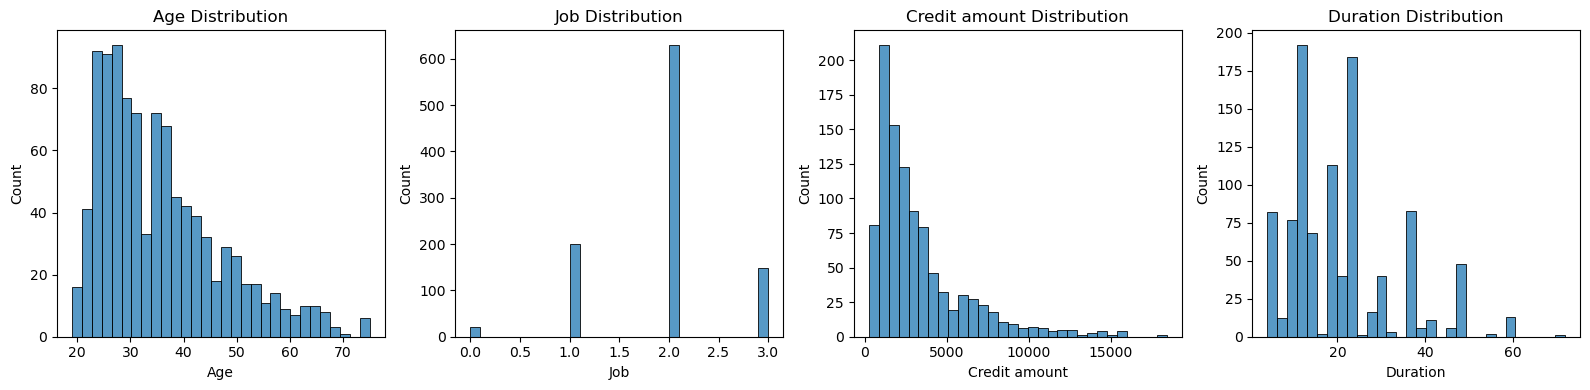

In [10]:
#Distribution of numerical cols

plt.figure(figsize=(16, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 4, i)
    sns.histplot(df[col], bins=30)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

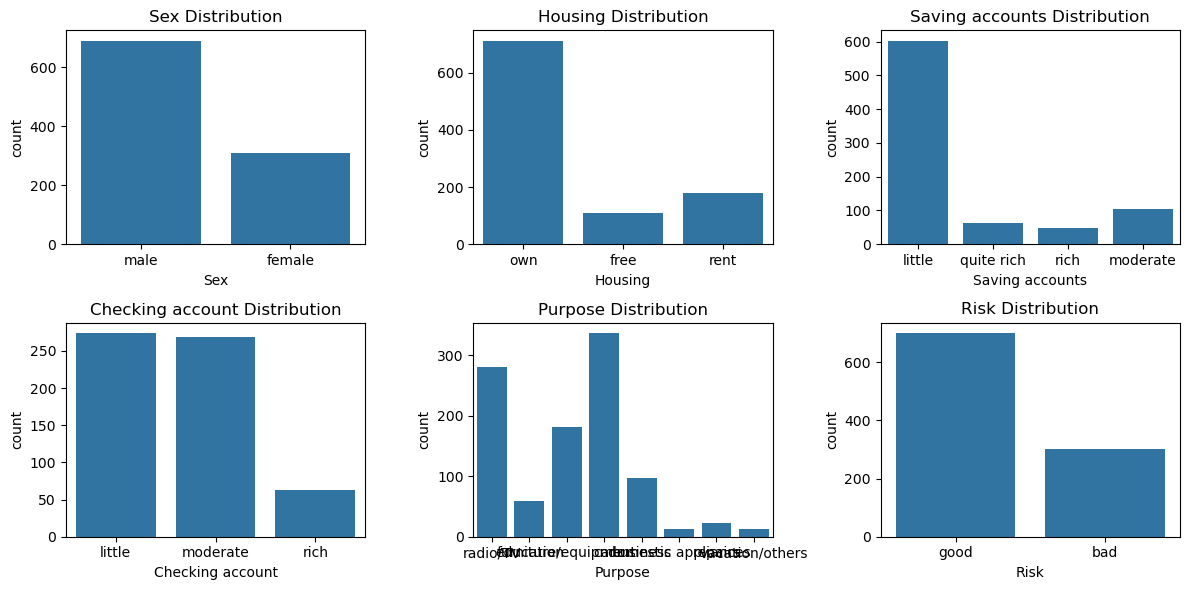

In [11]:
# distribution of categorical cols

plt.figure(figsize=(12, 6))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()

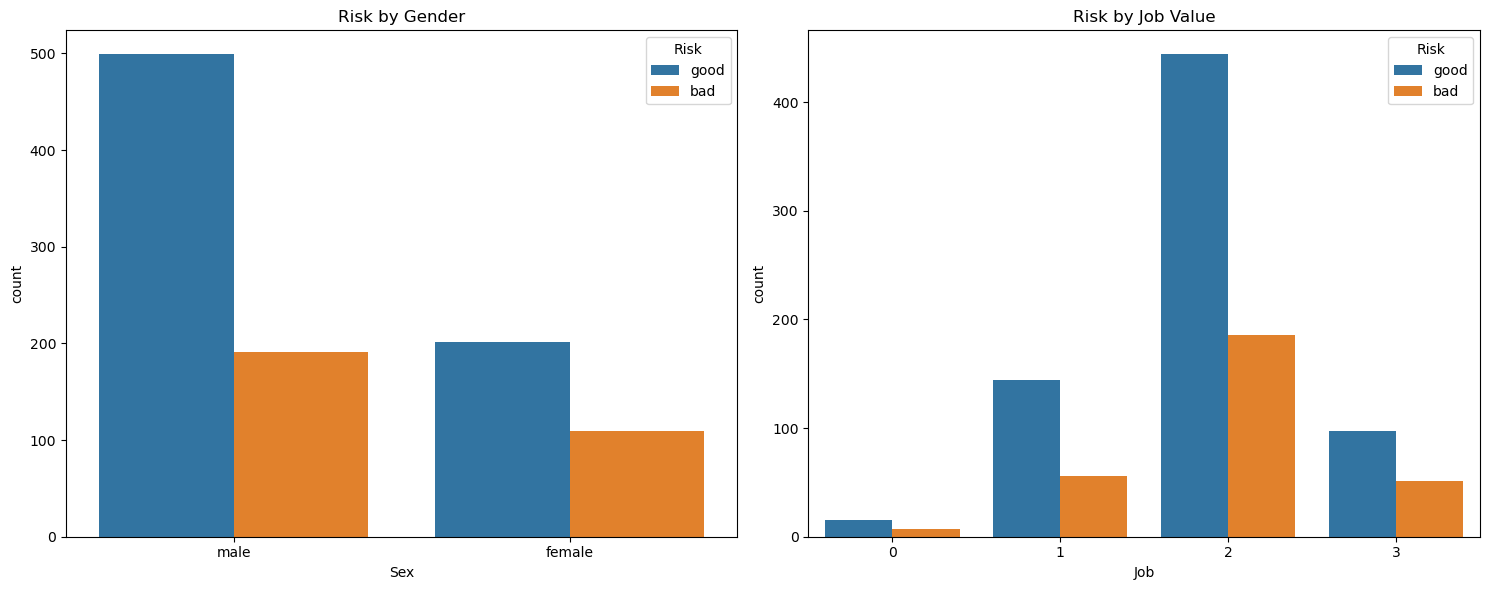

In [12]:
# bivariate analysis

plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)
sns.countplot(x="Sex", hue="Risk", data=df)
plt.title("Risk by Gender")

plt.subplot(1,2,2)
sns.countplot(x="Job", hue="Risk", data=df)
plt.title("Risk by Job Value")

plt.tight_layout()
plt.show()

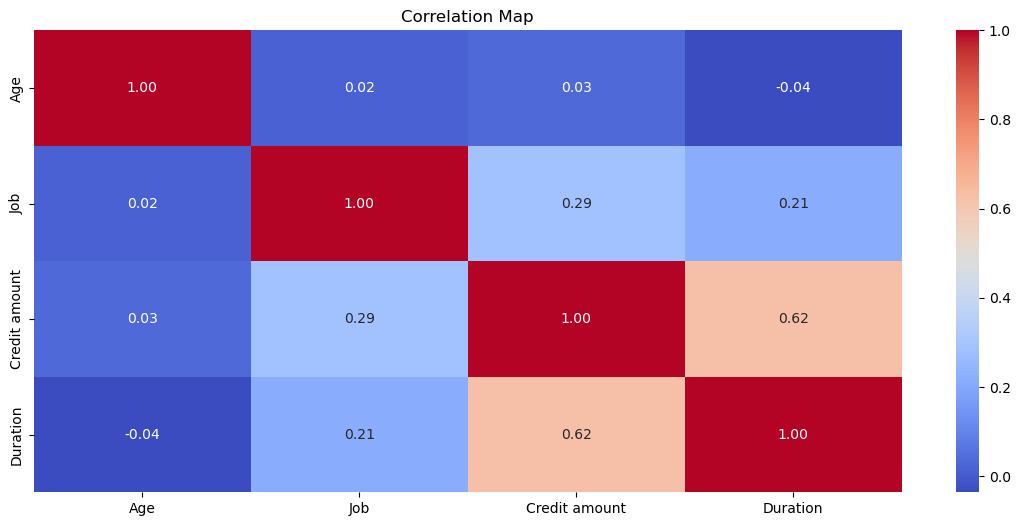

In [13]:
#correlation map

num_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(14, 6))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Map")
plt.show()

### **Phase 2: Data Preprocessing**

In [14]:
#handling missing values in alignment of domain knowledge

df["Saving accounts"] = df["Saving accounts"].fillna("None")
df["Checking account"] = df["Checking account"].fillna("None")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   1000 non-null   object
 5   Checking account  1000 non-null   object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


#### **Feature Engineering**

In [15]:
df["Monthly debt"] = df["Credit amount"] / df["Duration"]
df['loan_intensity'] = (df['Credit amount'] / 1000) * np.log1p(df['Duration'])
def age_risk(age):
    if age < 25:
        return 'high_risk' 
    elif age < 40:
        return 'low_risk'   
    elif age < 60:
        return 'medium_risk' 
    else:
        return 'high_risk' 
df['age_risk_group'] = df['Age'].apply(age_risk)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1000 non-null   int64  
 1   Sex               1000 non-null   object 
 2   Job               1000 non-null   int64  
 3   Housing           1000 non-null   object 
 4   Saving accounts   1000 non-null   object 
 5   Checking account  1000 non-null   object 
 6   Credit amount     1000 non-null   int64  
 7   Duration          1000 non-null   int64  
 8   Purpose           1000 non-null   object 
 9   Risk              1000 non-null   object 
 10  Monthly debt      1000 non-null   float64
 11  loan_intensity    1000 non-null   float64
 12  age_risk_group    1000 non-null   object 
dtypes: float64(2), int64(4), object(7)
memory usage: 101.7+ KB


#### **Feature Engineering using K means (unsupervised learning)**

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_feature = ['Age', 'Job', 'Credit amount', 'Duration', 'Monthly debt']

scaler = StandardScaler()
scaled_cluster = scaler.fit_transform(df[cluster_feature])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Customer segment"] = kmeans.fit_predict(scaled_cluster)
df["Customer segment"]

0      2
1      0
2      2
3      0
4      2
      ..
995    1
996    0
997    1
998    1
999    0
Name: Customer segment, Length: 1000, dtype: int32

In [17]:
#encoding

df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
df["Risk"] = df['Risk'].map({'good': 1, 'bad': 0})
df["Saving accounts"] = df['Saving accounts'].map({'None': 0, 'little': 1, 'moderate': 2, 'quite rich': 3, 'rich': 4})
df["Checking account"] = df['Checking account'].map({'None': 0, 'little': 1, 'moderate': 2, 'rich': 3})
categorical_cols = ['Housing', 'Saving accounts', 'Checking account','Purpose', 'age_risk_group']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          1000 non-null   int64  
 1   Sex                          1000 non-null   int64  
 2   Job                          1000 non-null   int64  
 3   Credit amount                1000 non-null   int64  
 4   Duration                     1000 non-null   int64  
 5   Risk                         1000 non-null   int64  
 6   Monthly debt                 1000 non-null   float64
 7   loan_intensity               1000 non-null   float64
 8   Customer segment             1000 non-null   int32  
 9   Housing_own                  1000 non-null   bool   
 10  Housing_rent                 1000 non-null   bool   
 11  Saving accounts_1            1000 non-null   bool   
 12  Saving accounts_2            1000 non-null   bool   
 13  Saving accounts_3  

### **Train Test Split**

In [39]:

from sklearn.model_selection import train_test_split

X = df.drop("Risk", axis=1)
y = df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size = 0.8, test_size=0.2)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain default rate: {y_train.mean():.2%}")
print(f"Test default rate: {y_test.mean():.2%}")


Train set: (800, 26)
Test set: (200, 26)

Train default rate: 69.88%
Test default rate: 70.50%


### **SMOTE Analysis**

In [40]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)


# **Phase 3: XGBoost Model Training** 

In [41]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X_xgb_train = X_train_sm
X_xgb_test = X_test
y_xgb_train = y_train_sm
y_xgb_test = y_test

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.1,
    min_child_weight = 10,
    gamma = 0.8,
    max_depth=4,
    reg_lambda = 0.5,
    subsample=0.8,
    reg_alpha = 0.0,
    colsample_bytree=1.0,
    eval_metric="auc",
    random_state=42
)

xgb_model.fit(X_xgb_train, y_xgb_train, eval_set=[(X_xgb_test, y_xgb_test)], verbose=10)

y_pred = xgb_model.predict(X_xgb_test)
y_proba = xgb_model.predict_proba(X_xgb_test)[:, 1]

best_threshold = 0.35
y_pred = (y_proba >= best_threshold).astype(int)

xgb_acc = accuracy_score(y_test, y_pred)
xgb_roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {xgb_acc:.4f}")
print(f"ROC-AUC: {xgb_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


[0]	validation_0-auc:0.77660
[10]	validation_0-auc:0.80328
[20]	validation_0-auc:0.81122
[30]	validation_0-auc:0.81428
[40]	validation_0-auc:0.82149
[50]	validation_0-auc:0.82270
[60]	validation_0-auc:0.82342
[70]	validation_0-auc:0.82474
[80]	validation_0-auc:0.82041
[90]	validation_0-auc:0.82161
[100]	validation_0-auc:0.81993
[110]	validation_0-auc:0.82113
[120]	validation_0-auc:0.81861
[130]	validation_0-auc:0.81560
[140]	validation_0-auc:0.81428
[150]	validation_0-auc:0.81103
[160]	validation_0-auc:0.81813
[170]	validation_0-auc:0.81608
[180]	validation_0-auc:0.81560
[190]	validation_0-auc:0.81296
[200]	validation_0-auc:0.81560
[210]	validation_0-auc:0.81584
[220]	validation_0-auc:0.81320
[230]	validation_0-auc:0.81043
[240]	validation_0-auc:0.81019
[250]	validation_0-auc:0.81344
[260]	validation_0-auc:0.81103
[270]	validation_0-auc:0.81188
[280]	validation_0-auc:0.81560
[290]	validation_0-auc:0.81380
[300]	validation_0-auc:0.81476
[310]	validation_0-auc:0.81380
[320]	validation_0-

### **Scaling Features**

In [21]:
X_train = X_train_sm.clip(lower=0)
X_test = X_test.clip(lower=0)

def fit_scaling(df):
    df = df.copy().astype(float)
    logged = np.log1p(df)
    mu_sigma = {}
    df_clean = logged.copy()
    for col in logged.columns:
        mu = logged[col].mean()
        sigma = logged[col].std()
        mu_sigma[col] = {"mu": mu, "sigma": sigma}
        df_clean[col] = (logged[col] - mu) / sigma 
    return df_clean, mu_sigma

def transform_scale(df, mu_sigma):
    df = df.copy().astype(float)
    logged = np.log1p(df)
    for col in df.columns:
        mu = mu_sigma[col]["mu"]
        sigma = mu_sigma[col]["sigma"]
        logged[col] = (logged[col] - mu) / sigma
    return logged

X_train, mu_sigma = fit_scaling(X_train)
X_test = transform_scale(X_test, mu_sigma)

print(len(X_train), len(X_test))


1118 200


# **Phase 4: Manual ANN Training** 

In [22]:
import torch
import torch.nn.functional as F

In [23]:
class ManualANN:

    def __init__(self, input_dim, hidden_dim1 = 32, hidden_dim2 = 16, learning_rate = 0.1, epoch=500):
        self.learning_rate = learning_rate
        self.epoch = epoch
        
        self.w1 = (torch.randn(input_dim, hidden_dim1) * (1/torch.sqrt(torch.tensor(float(input_dim))))).requires_grad_()
        self.b1 = torch.zeros(hidden_dim1, dtype=torch.float32, requires_grad=True)
        
        self.w2 = (torch.randn(hidden_dim1, hidden_dim2) * (1/torch.sqrt(torch.tensor(float(hidden_dim1))))).requires_grad_()
        self.b2 = torch.zeros(hidden_dim2, dtype=torch.float32, requires_grad=True)
        
        self.w3 = (torch.randn(hidden_dim2, 1) * (1/torch.sqrt(torch.tensor(float(hidden_dim2))))).requires_grad_()
        self.b3 = torch.zeros(1, dtype=torch.float32, requires_grad=True)


    def relu(self, z, alpha=0.01):
        return torch.where(z > 0, z, alpha * z)

    def sigmoid(self, z):
        return 1/(1+torch.exp(-z))

    def fit(self, X, y):
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

        for i in range(self.epoch):
            Z1 = X @ self.w1 + self.b1
            A1 = self.relu(Z1)
            
            Z2 = A1 @ self.w2 + self.b2
            A2 = self.relu(Z2)
            
            Z3 = A2 @ self.w3 + self.b3
            y_pred = self.sigmoid(Z3)

            eps = 1e-12
            y_pred_clip = torch.clamp(y_pred, eps, 1 - eps)
            loss = -(y * torch.log(y_pred_clip) + (1 - y) * torch.log(1 - y_pred_clip)).mean()

            loss.backward()

            with torch.no_grad():
                self.w1 -= self.learning_rate * (self.w1.grad + 0.0001 * self.w1)
                self.b1 -= self.learning_rate * self.b1.grad

                self.w2 -= self.learning_rate * (self.w2.grad + 0.0001 * self.w2)
                self.b2 -= self.learning_rate * self.b2.grad

                self.w3 -= self.learning_rate * (self.w3.grad + 0.0001 * self.w3)
                self.b3 -= self.learning_rate * self.b3.grad

                self.w1.grad.zero_()
                self.b1.grad.zero_()
                self.w2.grad.zero_()
                self.b2.grad.zero_()
                self.w3.grad.zero_()
                self.b3.grad.zero_()

            if i % 100 == 0:
                preds = (y_pred >= 0.5).float()
                acc = (preds == y).float().mean().item()
                print(f"Epoch {i:4d} | Loss={loss.item():.4f} | Acc={acc:.4f}")

    def predict(self, X):
        X = torch.tensor(X, dtype=torch.float32)
        Z1 = X @ self.w1 + self.b1
        A1 = self.relu(Z1)
        Z2 = A1 @ self.w2 + self.b2
        A2 = self.relu(Z2)
        Z3 = A2 @ self.w3 + self.b3
        y_pred = self.sigmoid(Z3)
        return (y_pred>=0.5).float().numpy()

    def predict_proba(self, X):
        X = torch.tensor(X, dtype=torch.float32)
        Z1 = X @ self.w1 + self.b1
        A1 = self.relu(Z1)
        Z2 = A1 @ self.w2 + self.b2
        A2 = self.relu(Z2)
        Z3 = A2 @ self.w3 + self.b3
        y_pred = self.sigmoid(Z3)
        return y_pred.detach().numpy().reshape(-1)

        

In [24]:
input_dim = X_train.shape[1]   
model = ManualANN(input_dim)
model.fit(X_train.values, y_train_sm.values)

Epoch    0 | Loss=0.7015 | Acc=0.5045
Epoch  100 | Loss=0.4682 | Acc=0.7835
Epoch  200 | Loss=0.3890 | Acc=0.8193
Epoch  300 | Loss=0.3587 | Acc=0.8381
Epoch  400 | Loss=0.3357 | Acc=0.8551


In [25]:
y_pred = model.predict(X_test.values)
y_pred = y_pred.reshape(-1)
y_true = y_test.values.reshape(-1)

acc = (y_pred == y_true).astype(float).mean()

y_scores = model.predict_proba(X_test.values)  
auc = roc_auc_score(y_test, y_scores)

print("ROC AUC:", auc)
print("Test Accuracy:", acc)


ROC AUC: 0.7914412789998797
Test Accuracy: 0.76


In [27]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

input_dim = X_train.shape[1]   
model = ManualANN(input_dim)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

y_pred = y_pred.reshape(-1)
y_true = y_test.reshape(-1)

acc = (y_pred == y_true).astype(float).mean()

print("Test Accuracy:", acc)


Epoch    0 | Loss=0.6538 | Acc=0.5890
Epoch  100 | Loss=0.0778 | Acc=0.9824
Epoch  200 | Loss=0.0516 | Acc=0.9868
Epoch  300 | Loss=0.0412 | Acc=0.9934
Epoch  400 | Loss=nan | Acc=0.3714
Test Accuracy: 0.37719298245614036


In [32]:
pip install lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283918 sha256=d954194c73c674d652f992afe3af5489d18b6bc3166618061026fbd9815022cc
  Stored in directory: c:\users\mahes\appdata\local\pip\cache\wheels\7c\04\5c\157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime
Note: you may need to restart the kernel to use updated packages.


In [33]:
pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ------------------- -------------------- 262.1/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 1.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [59]:
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)


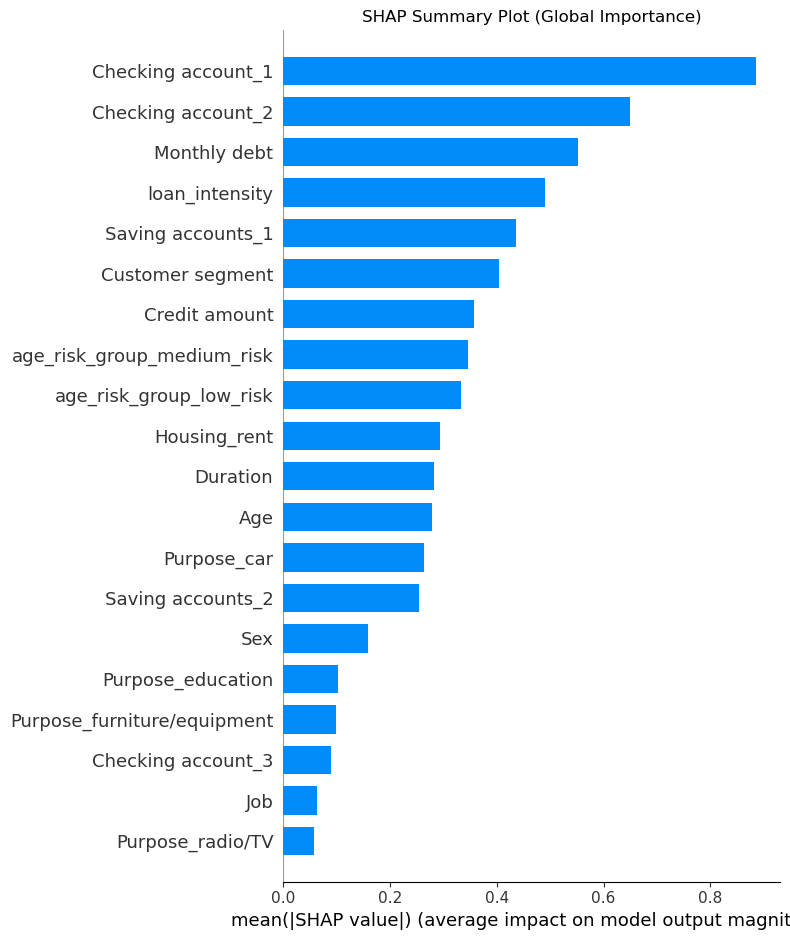

In [52]:
plt.figure(figsize=(8, 4))
plt.title("SHAP Summary Plot (Global Importance)")
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()

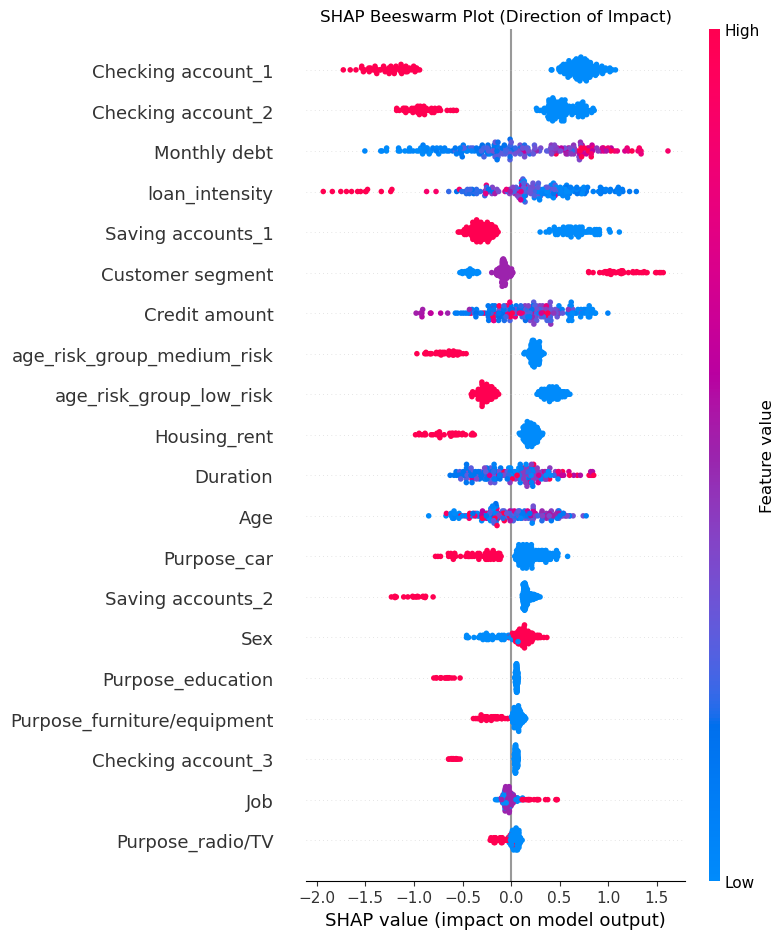

In [53]:
plt.figure(figsize=(8, 4))
plt.title("SHAP Beeswarm Plot (Direction of Impact)")
shap.summary_plot(shap_values, X_test)
plt.show()


Analyzing High-Risk Customer at Index: 0


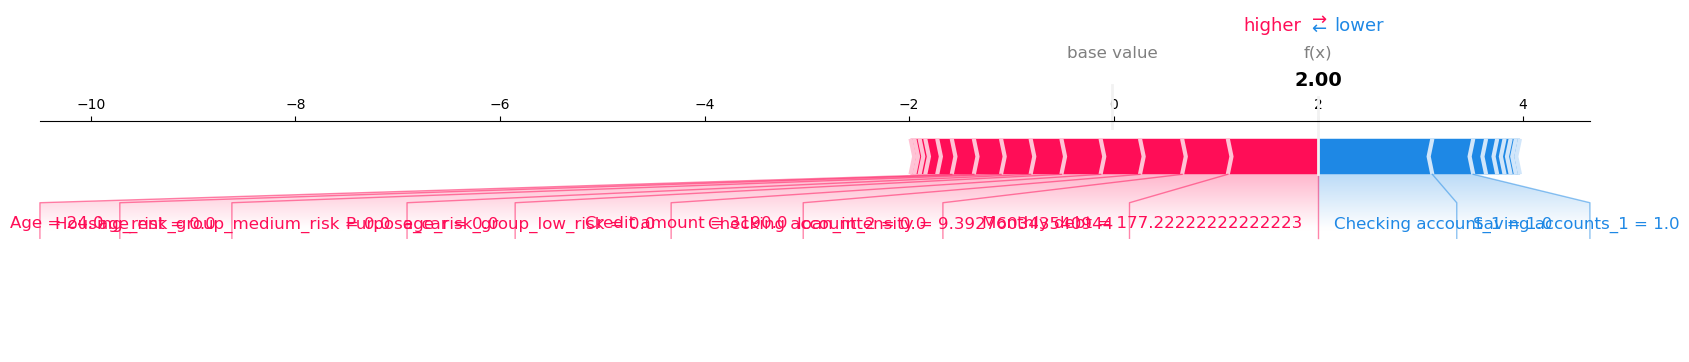

In [51]:
print(f"Analyzing High-Risk Customer at Index: {risk_idx}")

shap.initjs() 
force_plot = shap.force_plot(explainer.expected_value, shap_values[risk_idx,:], X_test.iloc[risk_idx,:], matplotlib=True)
plt.show()

In [57]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Good', 'Bad'],
    mode='classification'
)

print(f"\nLIME Explanation for Customer {risk_idx}:")
exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[risk_idx].values, 
    predict_fn=xgb_model.predict_proba
)



LIME Explanation for Customer 0:


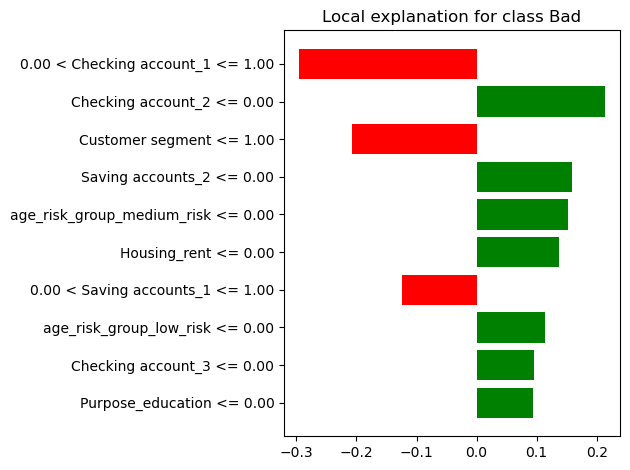

In [58]:
exp.as_pyplot_figure()
plt.tight_layout()
plt.show()